# **INTRODUCCION**

---


# -- **Trabajo Práctico:** Aprendizaje por Refuerzo en Mountain Car
# -- **Materia:** AA2
# -- **Alumno:** Gallo, Marcos
# -- **Profesora:** Diedrich, Ana Laura

## 1.2 Instalar librerias

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import deque
import random
import seaborn as sns
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

## 1.2 Reproducibilidad

In [ ]:
def set_seed(seed = 12, env=None):
    import random
    import numpy as np
    import torch

    # Semillas básicas
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)  # si usás CUDA

    # Para entornos deterministas en GPU (PyTorch)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Si se pasa un entorno Gymnasium, fijar sus semillas también
    if env is not None:
        env.reset(seed=seed)
        if hasattr(env, "action_space"):
            env.action_space.seed(seed)
        if hasattr(env, "observation_space"):
            env.observation_space.seed(seed)


# 2   **TAREAS**

---



# **2.1  Explicar cada detalle del entorno (observaciones, acciones, recompensa, etc)**

---



El entorno de Mountain-Carv0 tiene un control muy simple: moverse a la izquierda, (sin acción) o moverse a la derecha. Comienza con un coche en algún punto en el fondo del valle, y el objetivo es controlarlo hasta el pico derecho, donde está la bandera amarilla. El problema de este juego es que el coche no tiene suficiente potencia para acelerar cuesta arriba desde cero. El jugador tendrá que balancear el coche de un lado a otro del valle para coger el impulso suficiente para la subida.




🏁 Estado inicial y condición de fin (`done`)

- El estado inicial es aleatorio con:
-- posición entre –0.6 y –0.4
-- velocidad = 0


- El episodio termina cuando:
-- La posición del auto llega a ≥ 0.5 (cima derecha), o
-- Se superan 200 pasos (por defecto).



🏆 Objetivo:

- El objetivo es alcanzar la cima derecha en el menor número de pasos posibles. Se considera que el entorno está "resuelto" si se obtiene un promedio de recompensa ≥ –110 en 100 episodios consecutivos.


## Creación del entorno

In [ ]:

env = gym.make("MountainCar-v0")
set_seed(seed=12, env=env)
env.reset()

print("🚗 ENTORNO MOUNTAINCAR-V0")
print("=" * 50)

# Espacio de observación
obs_space = env.observation_space
print(f"Espacio de observación: {obs_space}")
print(f"  - Mínimos: {obs_space.low}")
print(f"  - Máximos: {obs_space.high}")
print(f"  - Dimensiones: {obs_space.shape}")

# Espacio de acción
action_space = env.action_space
print(f"Número de acciones: {action_space.n}")
print(f"Acciones: {['Izquierda (0)', 'Sin empuje (1)', 'Derecha (2)']}")


🚗 ENTORNO MOUNTAINCAR-V0
Espacio de observación: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
  - Mínimos: [-1.2  -0.07]
  - Máximos: [0.6  0.07]
  - Dimensiones: (2,)
Número de acciones: 3
Acciones: ['Izquierda (0)', 'Sin empuje (1)', 'Derecha (2)']


## MountainCar-v0 – Descripción del entorno

1. 🔢 Observaciones (env.observation_space)

```
obs_space = env.observation_space
print(f"Espacio de observación: {obs_space}")

salida: Espacio de observación: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
```
Tipo: `Box`, lo que indica un espacio continuo multidimensional.

Dimensión: `(2,)` → Hay 2 valores que definen el estado del auto en cada paso del tiempo:

El estado es un vector de 2 valores continuos:

-- position (posición del auto): va de –1.2 (izquierda) a 0.6 (cima derecha).

-- velocity (velocidad): va de –0.07 a 0.07.

📌 Comparación con FrozenLake-v1:

--En FrozenLake los estados eran discretos y numerados (0 a 15).

--En MountainCar el estado es continuo, por lo tanto no se puede usar una tabla Q directamente a menos que se discretice el espacio.




2. 🎮 Acciones (env.action_space)


```
action_space = env.action_space
print(f"Número de acciones: {action_space.n}")
print(f"Acciones: {['Izquierda (0)', 'Sin empuje (1)', 'Derecha (2)']}")
```
**Hay 3 acciones discretas:**

0: Acelerar hacia la izquierda.

1: No acelerar (mantener).

2: Acelerar hacia la derecha.



3. 🧮 Recompensas (reward)

-- En cada paso, el agente recibe una recompensa de `-1`, sin importar qué acción tome.

-- Objetivo: alcanzar la cima de la colina `(posición x ≥ 0.5)` lo más rápido posible.

-- Esto genera un incentivo para minimizar el número de pasos (porque cada paso resta 1).

-- No hay recompensa positiva hasta llegar a la meta.


 4. 🏁 Condiciones de finalización (done)
El episodio termina si:

- El coche alcanza la cima: `position >= 0.5`.

- Se supera el límite de pasos: 200 pasos máximo por episodio (según `env.spec.max_episode_steps`).

- Para reutilizar el código base del TP1, los cambios principales están en cómo se maneja el espacio de estados:

-- En FrozenLake: `env.observation_space.n`

-- En MountainCar: se debe usar `env.observation_space.low` y `.high` y luego discretizar ese espacio en `n_bins`.



🧱 **Discretizar el espacio continuo**:

Es dividir cada dimensión del estado (position, velocity) en un número finito de intervalos o "bins".
Así se puede representar cada estado con un índice entero discreto, como en FrozenLake.

Ejemplo:

- Position: de –1.2 a 0.6 → 20 bins

- Velocity: de –0.07 a 0.07 → 20 bins
- Total de combinaciones discretas: 20 × 20 = 400 estados



## Función para discretizar entorno

In [ ]:
# prompt: Crea una función para discretizar el espacio de estados continuos del entorno MountainCar-v0 en índices enteros

def crear_discretizador(env, bins=(20, 20)):
    """Devuelve función para convertir estados continuos a índices discretos"""
    obs_low = env.observation_space.low      # [-1.2  -0.07]
    obs_high = env.observation_space.high     # [0.6    0.07]}

    #se quiere dividir cada variable (posición y velocidad) en 20 partes, lo que nos da 21 bordes
    #[..., 1:-1] quita el primer y último valor, es decir, solo se conservan los 19 cortes internos que separan los 20 intervalos.
    posicion_bins = np.linspace(obs_low[0], obs_high[0], bins[0] + 1)[1:-1]
    velocidad_bins = np.linspace(obs_low[1], obs_high[1], bins[1] + 1)[1:-1]

    def discretizar_estado(estado):
        pos, vel = estado
        pos = np.clip(pos, obs_low[0], obs_high[0])
        vel = np.clip(vel, obs_low[1], obs_high[1])
        i = np.digitize(pos, posicion_bins)  # devuelve en qué intervalo cae cada valor (posición y velocidad), dando lugar a un par de índices (i, j).
        j = np.digitize(vel, velocidad_bins)
        return (i, j)

    return discretizar_estado

In [ ]:
set_seed(seed=12, env=env)
discretizar = crear_discretizador(env, bins=(20, 20))
# env.reset() en Gymnasium devuelve una tupla: (observation, info), por eso se accede a [0] para quedarnos con la observación (estado inicial).
estado_continuo = env.reset()[0]  # estado es una lista [pos, vel]
estado_discreto = discretizar(estado_continuo)

print("Estado continuo:", estado_continuo)
print("Estado discreto:", estado_discreto)


Estado continuo: [-0.41064942  0.        ]
Estado discreto: (np.int64(8), np.int64(10))


📦 ¿Qué devuelve esta función?

- Un estado como [–0.41, 0.0] →  (8, 10)

- Esto representa:

Posición: –0.4106 (entre –1.2 y 0.6)

Velocidad: 0.0 (entre –0.07 y 0.07)

La posición fue discretizada al bin 8

La velocidad fue discretizada al bin 10

- Estos números indican a qué segmento (bin) pertenece ese valor continuo según las divisiones que hicimos.

- Esto te permite indexar una Q-table como Q[pos_bin][vel_bin][accion], o una tabla plana con Q[estado_discreto, accion].

# **2.2 Visualización de la política**

---



In [ ]:
# prompt: Crea una función para visualizar comparativamente las políticas de tres agentes (Q-learning, DQN, y uno aleatorio) en MountainCar-v0, usando un grid de 20x20 de estados (posición, velocidad).
# Muestra en cada celda la acción elegida por cada agente como un símbolo. Incluye leyenda.

def visualizar_politicas_comparadas(agent_q, agent_dqn, agent_random, env, bins=(20, 20)):
    n_pos_bins, n_vel_bins = bins
    obs_low = env.observation_space.low
    obs_high = env.observation_space.high

   # Genera un grid regular en el espacio de estados: 20 valores de posición y 20 de velocidad → 400 puntos.
    pos_grid = np.linspace(obs_low[0], obs_high[0], n_pos_bins)
    vel_grid = np.linspace(obs_low[1], obs_high[1], n_vel_bins)

   # Se inicializan 3 matrices que guardarán la acción óptima elegida por cada agente para cada celda del grid.
   #Cada valor en la matriz representa una acción: 0, 1 o 2.
    policy_q = np.zeros((n_pos_bins, n_vel_bins), dtype=int)
    policy_dqn = np.zeros((n_pos_bins, n_vel_bins), dtype=int)
    policy_random = np.zeros((n_pos_bins, n_vel_bins), dtype=int)

    for i in range(n_pos_bins):
        for j in range(n_vel_bins):
            pos = pos_grid[i]
            vel = vel_grid[j]
            estado = np.array([pos, vel])

            # Q-Learning tabular
            estado_disc = agent_q.discretizar_estado(estado) #Discretiza el estado continuo con el discretizador del agente Q.
            policy_q[i, j] = np.argmax(agent_q.q_table[estado_disc[0], estado_disc[1], :])#Busca la acción con mayor valor Q.

            # DQN
            estado_tensor = torch.FloatTensor(estado).unsqueeze(0).to(agent_dqn.device) #Convierte el estado en tensor.
            with torch.no_grad():
                q_values = agent_dqn.q_network(estado_tensor) #Pasa por la red y toma la acción con Q máximo.
            policy_dqn[i, j] = q_values.argmax().item()

            # Política Aleatoria
            policy_random[i, j] = np.random.choice(env.action_space.n) #cción aleatoria entre 0, 1, 2.

    def get_symbol(action):
        return {0: '⬅️', 1: '•', 2: '➡️'}.get(action, '?')

    # Visualizar
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    titles = ["Q-Learning Tabular", "Deep Q-Network (DQN)", "Política Aleatoria"]
    policies = [policy_q, policy_dqn, policy_random]

    for ax, policy, title in zip(axes, policies, titles):
        sns.heatmap(policy, cmap="viridis", ax=ax, cbar=False, annot=False)
        ax.set_title(title)
        ax.set_xlabel("Velocidad")
        ax.set_ylabel("Posición")
        ax.invert_yaxis()

        # Agregar símbolos en cada celda
        for i in range(n_pos_bins):
            for j in range(n_vel_bins):
                simbolo = get_symbol(policy[i, j])
                ax.text(j + 0.5, i + 0.5, simbolo, ha='center', va='center', fontsize=10, color='white')

    # Agregar leyenda explicativa
    simbolos = ['⬅️ Acelerar izquierda (0)', '• Sin acción (1)', '➡️ Acelerar derecha (2)']
    leyenda = '\n'.join(simbolos)
    plt.figtext(0.5, -0.05, "Leyenda de acciones:\n" + leyenda, ha="center", fontsize=12)

    plt.tight_layout()
    plt.show()



🎯 Objetivo

- La función que se busca es que, dado una tabla Q, permita visualizar la política aprendida sobre el espacio discreto (position, velocity).


El espacio ha sido discretizado en `n_bins_pos × n_bins_vel`

Tenemos una tabla Q de dimensiones `[n_bins_pos, n_bins_vel, n_actions]`

La política óptima en cada estado es la acción con mayor valor Q: `argmax(Q[i, j])`



🔧 **Modificaciones para adaptar la visualización de política de FrozenLake a MountainCar-v0**


---



1. Tipo de entorno:


- FrozenLake: entorno completamente discreto.

- MountainCar-v0: entorno con espacio de estados continuo, requiere discretización previa.

2. Estructura de la política:

- FrozenLake: política representada como un vector plano de tamaño 16 (1D), donde cada valor representa una acción.

- MountainCar-v0: se trabaja con una Q-table tridimensional de tamaño [pos_bins, vel_bins, n_actions], por lo que se calcula la política como np.argmax(Q_table, axis=2).

3. Visualización gráfica:

- FrozenLake: se utilizaban símbolos de flechas (←, ↓, →, ↑) y un grid fijo 4x4 para representar la política.

- MountainCar-v0: se utiliza una malla de calor (heatmap) basada en bins de posición y velocidad, con color para representar la acción óptima.

4. Dependencia del entorno (env):

- FrozenLake: no era necesario acceder a env para la visualización.

- MountainCar-v0: se accede a env.observation_space.low y high para generar los ejes continuos de posición y velocidad.

5. Tamaño del espacio de estados:

- FrozenLake: tamaño fijo de 16 estados (4x4).

- MountainCar-v0: tamaño configurable según los bins, por ejemplo (20, 20) → 400 estados discretos.

6. Ejes del gráfico:

- FrozenLake: ejes sin etiquetas, solo símbolos en cada celda.

- MountainCar-v0: ejes etiquetados con valores numéricos reales (posición y velocidad) derivados del espacio continuo.

7. Representación de estados especiales:

- FrozenLake: representaba estados especiales (S Start, G Goal, H Holes) con anotaciones.

- MountainCar-v0: no hay estados especiales explícitos; todos los estados son del mismo tipo.



# **2.3 Entrenar Politica aleatoria, Q-tabular, DQN**

---



🟢 1. Política Aleatoria adaptada a MountainCar

In [ ]:
# prompt: Crea una clase PoliticaAleatoria para el entorno MountainCar-v0.
# Debe seleccionar acciones al azar (np.random.randint).
# Incluir un método entrenar(episodios) que registre la recompensa total por episodio y cuente los éxitos (cuando el auto alcanza posición ≥ 0.5).
# Mostrar progreso cada 200 episodios y calcular recompensa promedio y tasa de éxito final.
# Debe ser compatible con funciones que usan discretizar_estado, aunque no use una tabla Q.

class PoliticaAleatoria:
    """Política que selecciona acciones completamente al azar"""
    def __init__(self, env, bins=(20, 20)):
        self.env = env
        self.n_acciones = env.action_space.n
        self.nombre = "Política Aleatoria"
        self.discretizar_estado = crear_discretizador(env, bins)
        # Crea una función discretizar_estado para la compatibilidad con funciones que trabajan con políticas tabulares
        # (Verificar politicas comparadas)

    def seleccionar_accion(self, estado):
        """Selecciona una acción aleatoria"""
        return np.random.randint(self.n_acciones)

    def entrenar(self, episodios=2000):
        """Ejecuta la política aleatoria y registra métricas"""
        print(f"🎲 Evaluando {self.nombre}...")
        recompensas = []
        exitos = 0

        for episodio in range(episodios):
            estado, _ = self.env.reset()
            recompensa_total = 0
            terminado = False

            while not terminado:
                accion = self.seleccionar_accion(estado)
                estado, recompensa, terminado, truncated, _ = self.env.step(accion)
                recompensa_total += recompensa

                if truncated:  # Por si termina por timeout
                    break

            # Éxito si llega a la cima de la colina
            if estado[0] >= 0.5:
                exitos += 1
            recompensas.append(recompensa_total)

            if (episodio + 1) % 200 == 0:
                tasa_exito = exitos / (episodio + 1)  # Da feedback progresivo de la tasa de éxito.
                print(f"Episodio {episodio + 1}: Tasa de éxito = {tasa_exito:.3f}")

        tasa_exito_final = exitos / episodios
        recompensa_promedio_aleatorio= np.mean(recompensas)

        print(f"\n📊 Resultados {self.nombre}:")
        print(f"Tasa de éxito final: {tasa_exito_final:.3f}")
        print(f"Recompensa promedio: {recompensa_promedio_aleatorio:.3f}")



        return recompensas, tasa_exito_final, recompensa_promedio_aleatorio




🔄 Cambios necesarios
1. 📌 Discretización del espacio de estados
- Antes (FrozenLake): No era necesario discretizar, el estado ya era un índice entero.

- Ahora (MountainCar): El estado es continuo (`[posición, velocidad]`), se necesita:
-- Definir número de bins por dimensión.
-- Utilizar `np.digitize` para mapear valores a índices discretos.
-- Se implementa con la función `crear_discretizador(env, bins=(20, 20))`

ACLARACION: La clase PoliticaAleatoria no usa la discretización del estado porque no la necesita para su lógica de toma de decisiones. El estado puede ser continuo, discreto, una imagen o cualquier otra cosa, solo importa cuántas acciones hay (`env.action_space.n`). Se usa para la compatibilidad con la funcion que luego comparará las políticas  `(Verificar_politicas_comparadas)`

2. 🎯 Criterio de éxito (para métrica `tasa de éxito`)

Antes: El éxito se definía como alcanzar un estado objetivo discreto (`estado == objetivo`).

Ahora: Se considera éxito si el coche alcanza la cima:

`if estado[0] >= 0.5: exitos += 1`

3. ⏱️ Límite de pasos

- Antes: FrozenLake suele terminar en pocos pasos o por truncado.

- Ahora: MountainCar tiene `max_episode_steps` definido por Gym (generalmente 200).

- No hace falta imponer un límite artificial adicional. (<100)

4. 🧪 Inicialización de los agentes

Todos los agentes ahora reciben como argumento el entorno completo `env` (no solo` n_acciones`), para poder usar sus propiedades (por ejemplo, los límites del espacio de observación) durante la discretización.

En Frozen Lake solo precisaba el n_acciones

In [ ]:
politica = PoliticaAleatoria(env)
recompensas_aleatorio, tasa_exito_aleatorio, recompensa_promedio_aleatorio = politica.entrenar(episodios=2000)


🎲 Evaluando Política Aleatoria...
Episodio 200: Tasa de éxito = 0.000
Episodio 400: Tasa de éxito = 0.000
Episodio 600: Tasa de éxito = 0.000
Episodio 800: Tasa de éxito = 0.000
Episodio 1000: Tasa de éxito = 0.000
Episodio 1200: Tasa de éxito = 0.000
Episodio 1400: Tasa de éxito = 0.000
Episodio 1600: Tasa de éxito = 0.000
Episodio 1800: Tasa de éxito = 0.000
Episodio 2000: Tasa de éxito = 0.000

📊 Resultados Política Aleatoria:
Tasa de éxito final: 0.000
Recompensa promedio: -200.000


🔵 2. Q-Learning Tabular adaptado a MountainCar

In [ ]:
# prompt: Crea una clase QLearningTabular para entrenar un agente Q-learning en MountainCar-v0, discretizando el espacio de estados con bins.
# Debe incluir métodos seleccionar_accion, actualizar_q, decay_epsilon, entrenar y evaluar.
# Durante el entrenamiento, registra recompensas, tasa de éxito y tiempo total.
# En evaluar mide recompensa promedio y tasa de éxito.
# Muestra estadísticas cada 200 episodios.


import time
class QLearningTabular:
    """QLearning adaptado para entornos con espacio de estado continuo como MountainCar-v0"""

    def __init__(self, env, bins=(20, 20), lr=0.1, gamma=0.99, epsilon=1.0):
        self.env = env
        self.n_acciones = env.action_space.n
        self.lr = lr # cuánto se ajusta el valor de Q
        self.gamma = gamma # Factor de descuento (valor futuro esperado)
        self.epsilon = epsilon # Probabilidad inicial de explorar (tomar acción aleatoria)
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.01
        self.nombre = "Q-Learning Tabular"

        # Discretizador: La Q-table tiene forma (20, 20, 3), porque:
                         # 20 bins de posición × 20 de velocidad = 400 estados discretos
                         # 3 posibles acciones (izquierda, no hacer nada, derecha)
        self.discretizar_estado = crear_discretizador(env, bins=bins)
        self.q_table = np.zeros(bins + (self.n_acciones,))

        # Tracking
        self.recompensas_entrenamiento = []
        self.epsilons = []


    def seleccionar_accion(self, estado, entrenando=True):
        estado_d = self.discretizar_estado(estado) # Convierte el estado continuo → discreto:
        if entrenando and np.random.random() < self.epsilon: # Con probabilidad epsilon, elige aleatoriamente (exploración)
            return np.random.randint(self.n_acciones)
        else:
            return np.argmax(self.q_table[estado_d]) # Si no, elige la acción con mayor valor Q (explotación)

    def actualizar_q(self, estado, accion, recompensa, siguiente_estado, terminado): # Actualiza el valor de Q usando la fórmula de Bellman:
        estado_d = self.discretizar_estado(estado)     #  Se discretizan tanto el estado actual como el siguiente
        siguiente_d = self.discretizar_estado(siguiente_estado)
        target = recompensa + self.gamma * np.max(self.q_table[siguiente_d]) * (not terminado) # Si el episodio terminó (terminado), no se considera el valor futuro (max(Q(s′)) * 0)
        self.q_table[estado_d][accion] += self.lr * (target - self.q_table[estado_d][accion])

    def decay_epsilon(self):        # Después de cada episodio, epsilon disminuye suavemente para ir explorando menos y explotando más lo aprendido.
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def entrenar(self, episodios=2000):
        print(f"🤖 Entrenando {self.nombre}...")
        recompensas = []
        exitos_ventana = deque(maxlen=100)
        exitos_totales = 0

        inicio = time.time()

        for ep in range(1, episodios + 1):
            estado, _ = self.env.reset()  # Reinicia el entorno.
            recompensa_total = 0
            terminado = False
            truncado = False

            while not terminado and not truncado:
                accion = self.seleccionar_accion(estado) # Ejecuta acciones usando seleccionar_accion.
                siguiente_estado, recompensa, terminado, truncado, _ = self.env.step(accion)
                self.actualizar_q(estado, accion, recompensa, siguiente_estado, terminado) # Actualiza la tabla Q con actualizar_q.
                estado = siguiente_estado
                recompensa_total += recompensa # Acumula la recompensa total.

            # Se considera éxito solo si llegó a la cima (0.5) Y fue "terminated"

            #if terminado and estado[0] >= 0.5:
            if estado[0] >= self.env.unwrapped.goal_position:
                exitos_ventana.append(1)
                exitos_totales += 1
            else:
                exitos_ventana.append(0)

            recompensas.append(recompensa_total)
            self.epsilons.append(self.epsilon)
            self.decay_epsilon() # Aplica decay_epsilon.

            if ep % 200 == 0:    # Imprime métricas cada 200 episodios:
                tasa_local = np.mean(exitos_ventana) # Tasa de éxito en últimos 100 episodios (tasa_local)
                tasa_global = exitos_totales / ep    # Tasa de éxito global (tasa_global)
                print(f"Episodio {ep}: Tasa éxito = {tasa_local:.3f}, "
                      f"Epsilon = {self.epsilon:.3f}, Recompensa media = {np.mean(recompensas[-100:]):.2f}") #Recompensa promedio reciente

        duracion = time.time() - inicio
        self.tiempo_entrenamiento = duracion
        self.recompensas_entrenamiento = recompensas
        tasa_exito_final = exitos_totales / episodios

        print(f"\n✅ Entrenamiento {self.nombre} completado!")
        print(f"Tasa de éxito final: {tasa_exito_final:.3f}")
        print(f"⏱️ Tiempo total: {duracion:.2f} s | Promedio por episodio: {duracion / episodios:.4f} s")
        return recompensas, duracion



    def evaluar(self, episodios=100):
        print(f"📊 Evaluando {self.nombre} (sin exploración)...")
        exitos = 0
        recompensas = []
        goal_pos = self.env.unwrapped.goal_position  # Usamos atributo del entorno

        for _ in range(episodios):
            estado, _ = self.env.reset()
            recompensa_total = 0
            terminado = False
            truncado = False

            while not terminado and not truncado:
                accion = self.seleccionar_accion(estado, entrenando=False)
                estado, recompensa, terminado, truncado, _ = self.env.step(accion)
                recompensa_total += recompensa

        # Éxito = si llega a la cima (sin importar 'terminado')
            if estado[0] >= goal_pos:
                exitos += 1

            recompensas.append(recompensa_total)

        tasa_exito = exitos / episodios
        print(f"Tasa de éxito eval: {tasa_exito:.3f}")
        print(f"Recompensa promedio eval: {np.mean(recompensas):.2f}")
        return recompensas, tasa_exito


### Adaptaciones para MountainCar-v0

- **Discretización de estados**: se añadió uso de `crear_discretizador()` para transformar el espacio continuo `[posición, velocidad]` en índices discretos.
- **Inicialización**: ahora se pasa `env` en lugar de `n_estados` para obtener automáticamente los límites del espacio de observación.
- **Q-table 3D**: la tabla Q ahora es de tamaño `(pos_bins, vel_bins, acciones)` en lugar de `(n_estados, acciones)`.
- **Criterio de éxito**: se considera que el episodio fue exitoso si `if recompensa == 0` (el coche llegó a la cima).
- **Se eliminó**: el chequeo artificial de `pasos < 100`, ya que `MountainCar` ya tiene un límite de pasos por defecto en `env`.



In [ ]:
# Inicializar agente Q-Learning con discretización (por ejemplo, 20x20)
agente_q = QLearningTabular(env, bins=(20, 20))

# Entrenar el agente
recompensas_qlearning, duracion_qlearning = agente_q.entrenar(episodios=2000)


🤖 Entrenando Q-Learning Tabular...
Episodio 200: Tasa éxito = 0.000, Epsilon = 0.367, Recompensa media = -200.00
Episodio 400: Tasa éxito = 0.000, Epsilon = 0.135, Recompensa media = -200.00
Episodio 600: Tasa éxito = 0.000, Epsilon = 0.049, Recompensa media = -200.00
Episodio 800: Tasa éxito = 0.090, Epsilon = 0.018, Recompensa media = -198.20
Episodio 1000: Tasa éxito = 0.160, Epsilon = 0.010, Recompensa media = -198.31
Episodio 1200: Tasa éxito = 0.150, Epsilon = 0.010, Recompensa media = -197.38
Episodio 1400: Tasa éxito = 0.500, Epsilon = 0.010, Recompensa media = -187.14
Episodio 1600: Tasa éxito = 0.450, Epsilon = 0.010, Recompensa media = -192.51
Episodio 1800: Tasa éxito = 0.010, Epsilon = 0.010, Recompensa media = -199.54
Episodio 2000: Tasa éxito = 0.440, Epsilon = 0.010, Recompensa media = -188.74

✅ Entrenamiento Q-Learning Tabular completado!
Tasa de éxito final: 0.196
⏱️ Tiempo total: 52.32 s | Promedio por episodio: 0.0262 s


In [ ]:
# Revisión del aprendizaje de la tabla Q
q = agente_q.q_table
print("Máximo valor Q:", np.max(q))
print("Promedio valor Q:", np.mean(q))
print("Acción óptima por estado ejemplo:")
for x in range(0, 20, 5):
    for v in range(0, 20, 5):
        print(f"[{x},{v}] → Acción: {np.argmax(q[x, v])}")


Máximo valor Q: 0.0
Promedio valor Q: -18.764814293582763
Acción óptima por estado ejemplo:
[0,0] → Acción: 0
[0,5] → Acción: 0
[0,10] → Acción: 1
[0,15] → Acción: 0
[5,0] → Acción: 0
[5,5] → Acción: 0
[5,10] → Acción: 2
[5,15] → Acción: 2
[10,0] → Acción: 0
[10,5] → Acción: 0
[10,10] → Acción: 1
[10,15] → Acción: 1
[15,0] → Acción: 0
[15,5] → Acción: 0
[15,10] → Acción: 0
[15,15] → Acción: 2


- Esto instancia el agente Q-learning con una tabla Q(s,a) de tamaño (20, 20, 3).

Usa:

-- Discretización: 20 intervalos de posición y 20 de velocidad.

-- Aprendizaje tabular: q_table[pos_bin][vel_bin][accion]
- Al entrenar: Corre 2000 episodios de entrenamiento.

Cada episodio el agente:

-- Parte desde un estado inicial aleatorio.

-- Toma acciones (usando epsilon-greedy, balance entre exploración y explotación en el aprendizaje por refuerzo).

-- Actualiza la tabla Q según la experiencia.

Al finalizar:

-- Imprime estadísticas de éxito.

-- Retorna una lista con la recompensa total por episodio.

In [ ]:
print("🔍 Ejemplo de estado → acción:")
estado, _ = env.reset()
print("Estado:", estado)
print("Acción elegida por la política:", agente_q.seleccionar_accion(estado, entrenando=False))


# Evaluación
env_eval = gym.make("MountainCar-v0")
set_seed(seed=12, env=env_eval)
agente_q.env = env_eval  # reemplazás el entorno en el agente
recompensas, tasa_exito_qlearning = agente_q.evaluar(episodios=100)


🔍 Ejemplo de estado → acción:
Estado: [-0.4901938  0.       ]
Acción elegida por la política: 0
📊 Evaluando Q-Learning Tabular (sin exploración)...
Tasa de éxito eval: 0.510
Recompensa promedio eval: -182.80


- Ejecuta 100 episodios (juegos completos).

En cada episodio:

-- Empieza desde el estado inicial del entorno.

-- Elige acciones con explotación pura (no explora):
entrenando=False → usa solo la acción con mayor valor Q.

-- Acumula la recompensa total por episodio.

-- Registra si llegó a la cima (estado[0] >= 0.5 y terminó correctamente).

Calcula:

-- recompensas: lista con la recompensa total obtenida en cada episodio.

-- tasa_exito_qlearning: proporción de episodios exitosos (donde llegó a la cima).


🔴 3. Deep Q-Network (DQN) adaptado a MountainCar

In [ ]:
class DQN(nn.Module):
  """Red neuronal para aproximar la función Q"""
  def __init__(self, input_size, hidden_size, output_size):
      super(DQN, self).__init__()
      self.network = nn.Sequential(
          nn.Linear(input_size, hidden_size),
          nn.ReLU(),
          nn.Linear(hidden_size, hidden_size),
          nn.ReLU(),
          nn.Linear(hidden_size, output_size)
      )

  def forward(self, x):
      return self.network(x)

In [ ]:

class DQNAgent:
    def __init__(self, state_size, action_size, lr=0.001, gamma=0.99, epsilon=1.0):
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.01
        self.learning_rate = lr
        self.nombre = "Deep Q-Network (DQN)"

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"🖥️ Usando dispositivo: {self.device}")

        hidden_size = 128
        self.q_network = DQN(state_size, hidden_size, action_size).to(self.device)
        self.target_network = DQN(state_size, hidden_size, action_size).to(self.device)
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.update_target_network()

        self.memory = deque(maxlen=10000)
        self.batch_size = 64
        self.update_target_frequency = 100
        self.step_count = 0

        self.losses = []
        self.recompensas_entrenamiento = []
        self.epsilons = []

    def remember(self, estado, accion, recompensa, siguiente_estado, terminado):
        self.memory.append((estado, accion, recompensa, siguiente_estado, terminado))

    def seleccionar_accion(self, estado, entrenando=True):
        if entrenando and np.random.random() < self.epsilon:
            return random.randrange(self.action_size)

        estado_tensor = torch.FloatTensor(estado).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.q_network(estado_tensor)
        return q_values.argmax().item()

    def replay(self):
        if len(self.memory) < self.batch_size:
            return

        batch = random.sample(self.memory, self.batch_size)
        estados, acciones, recompensas, siguientes_estados, terminados = zip(*batch)

        estados_tensor = torch.FloatTensor(estados).to(self.device)
        acciones_tensor = torch.LongTensor(acciones).unsqueeze(1).to(self.device)
        recompensas_tensor = torch.FloatTensor(recompensas).to(self.device)
        siguientes_tensor = torch.FloatTensor(siguientes_estados).to(self.device)
        terminados_tensor = torch.BoolTensor(terminados).to(self.device)

        current_q = self.q_network(estados_tensor).gather(1, acciones_tensor).squeeze()

        with torch.no_grad():
            max_next_q = self.target_network(siguientes_tensor).max(1)[0]
            target_q = recompensas_tensor + (self.gamma * max_next_q * (~terminados_tensor))

        loss = F.mse_loss(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.losses.append(loss.item())

    def update_target_network(self):
        self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

    def entrenar(self, env, episodios=2000):
        print(f"🤖 Entrenando {self.nombre}...")
        recompensas = []
        exitos_ventana = deque(maxlen=100)

        inicio = time.time()  # ⏱️ Inicia temporizador

        for ep in range(episodios):
            estado, _ = env.reset()
            recompensa_total = 0
            terminado = False
            pasos = 0

            while not terminado:
                accion = self.seleccionar_accion(estado)
                siguiente_estado, recompensa, terminado, truncated, _ = env.step(accion)
                if truncated:
                    terminado = True

                self.remember(estado, accion, recompensa, siguiente_estado, terminado)
                self.replay()
                estado = siguiente_state = siguiente_estado
                recompensa_total += recompensa
                pasos += 1
                self.step_count += 1

                if self.step_count % self.update_target_frequency == 0:
                    self.update_target_network()

            if estado[0] >= 0.5:
                exitos_ventana.append(1)
            else:
                exitos_ventana.append(0)

            recompensas.append(recompensa_total)
            self.epsilons.append(self.epsilon)
            self.decay_epsilon()

            if (ep + 1) % 200 == 0:
                tasa = np.mean(exitos_ventana)
                loss_prom = np.mean(self.losses[-100:]) if len(self.losses) > 0 else 0
                print(f"Episodio {ep + 1}: Tasa éxito = {tasa:.3f}, "
                      f"Epsilon = {self.epsilon:.3f}, Loss = {loss_prom:.4f}")

        duracion_dqn = time.time() - inicio  # ⏱️ Fin de temporizador
        self.tiempo_entrenamiento = duracion_dqn  # (opcional)

        self.recompensas_entrenamiento = recompensas
        print(f"\n✅ Entrenamiento {self.nombre} completado!")
        return recompensas, duracion_dqn

    def evaluar(self, env, episodios=100):
        print(f"📊 Evaluando {self.nombre}...")
        exitos = 0
        recompensas = []

        for _ in range(episodios):
            estado, _ = env.reset()
            recompensa_total = 0
            terminado = False

            while not terminado:
                accion = self.seleccionar_accion(estado, entrenando=False)
                estado, recompensa, terminado, truncated, _ = env.step(accion)
                if truncated:
                    terminado = True
                recompensa_total += recompensa

            if estado[0] >= 0.5:
                exitos += 1
            recompensas.append(recompensa_total)

        tasa_exito = exitos / episodios
        print(f"Tasa de éxito eval: {tasa_exito:.3f}")
        print(f"Recompensa promedio eval: {np.mean(recompensas):.2f}")
        return recompensas, tasa_exito


# Adaptación de DQNAgent a MountainCar-v0

## 🧠 Cambio clave

Originalmente el agente DQN trabajaba con estados discretos (ej: FrozenLake). Para MountainCar, que tiene observaciones continuas (posición y velocidad), se realizaron los siguientes cambios:

## 🔧 Cambios implementados

- ❌ Se eliminó `state_to_onehot`. En MountainCar no se usa codificación one-hot.
- ✅ Se trabaja directamente con vectores de estado de tamaño `state_size=2` como entradas de la red neuronal.
- ✅ `remember()` guarda directamente los vectores reales en lugar de codificaciones.
- ✅ `seleccionar_accion()` convierte el vector de estado a tensor y lo pasa por la red.
- ✅ `replay()` toma muestras del buffer y trabaja con vectores continuos directamente.
- ✅ Se añadió criterio de éxito específico del entorno (`estado[0] >= 0.5` → llegó a la cima).
- ✅ Compatible con renderización y evaluación del entorno `MountainCar-v0`.

## 📈 Redes y arquitectura

La red `DQN` permanece igual, con capas lineales de tamaño configurable (por defecto 128).

## 💡 Resultado

El agente DQN ahora es totalmente funcional para entornos con espacios de observación continuos como MountainCar.


In [ ]:

# Crear entorno
env = gym.make("MountainCar-v0", render_mode=None)
set_seed(env=env)
state_size = env.observation_space.shape[0]  # 2 (posición, velocidad)
action_size = env.action_space.n             # 3 (izquierda, no hacer nada, derecha)

# Inicializar agente
agent = DQNAgent(state_size, action_size)

# Entrenamiento
recompensas_dqn, duracion_dqn = agent.entrenar(env, episodios=2000)



🖥️ Usando dispositivo: cpu
🤖 Entrenando Deep Q-Network (DQN)...
Episodio 200: Tasa éxito = 0.000, Epsilon = 0.367, Loss = 10.3898
Episodio 400: Tasa éxito = 0.850, Epsilon = 0.135, Loss = 3.3453
Episodio 600: Tasa éxito = 0.990, Epsilon = 0.049, Loss = 0.5894
Episodio 800: Tasa éxito = 0.990, Epsilon = 0.018, Loss = 0.4462
Episodio 1000: Tasa éxito = 1.000, Epsilon = 0.010, Loss = 0.2707
Episodio 1200: Tasa éxito = 1.000, Epsilon = 0.010, Loss = 0.3223
Episodio 1400: Tasa éxito = 1.000, Epsilon = 0.010, Loss = 0.2114
Episodio 1600: Tasa éxito = 1.000, Epsilon = 0.010, Loss = 0.2210
Episodio 1800: Tasa éxito = 0.980, Epsilon = 0.010, Loss = 0.1719
Episodio 2000: Tasa éxito = 1.000, Epsilon = 0.010, Loss = 0.2474

✅ Entrenamiento Deep Q-Network (DQN) completado!


In [ ]:
# Evaluación
set_seed(env=env)
_ ,tasa_exito_dqn = agent.evaluar(env, episodios=100)

📊 Evaluando Deep Q-Network (DQN)...
Tasa de éxito eval: 1.000
Recompensa promedio eval: -104.59


#  **2.4 Compare el desempeño de las políticas entrenadas en 2.3**

---



In [ ]:
print("🏆 COMPARACIÓN FINAL DE AGENTES")
print("=" * 50)
print(f"Política Aleatoria:    Tasa de éxito = {tasa_exito_aleatorio:.3f}")
print(f"Política Aleatoria:    Recompensa promedio = {recompensa_promedio_aleatorio:.3f}")
print(f"Q-Learning Tabular:    Tasa de éxito = {tasa_exito_qlearning:.3f}")
print(f"Q-Learning Tabular:    Recompensa promedio = {np.mean(recompensas_qlearning):.3f}")
print(f"Deep Q-Network (DQN):  Tasa de éxito = {tasa_exito_dqn:.3f}")
print(f"Deep Q-Network (DQN):  Recompensa promedio = {np.mean(recompensas_dqn):.3f}")

🏆 COMPARACIÓN FINAL DE AGENTES
Política Aleatoria:    Tasa de éxito = 0.000
Política Aleatoria:    Recompensa promedio = -200.000
Q-Learning Tabular:    Tasa de éxito = 0.510
Q-Learning Tabular:    Recompensa promedio = -195.416
Deep Q-Network (DQN):  Tasa de éxito = 1.000
Deep Q-Network (DQN):  Recompensa promedio = -130.201


## **2.4.a)** **Visualizar politicas comparadas**

---



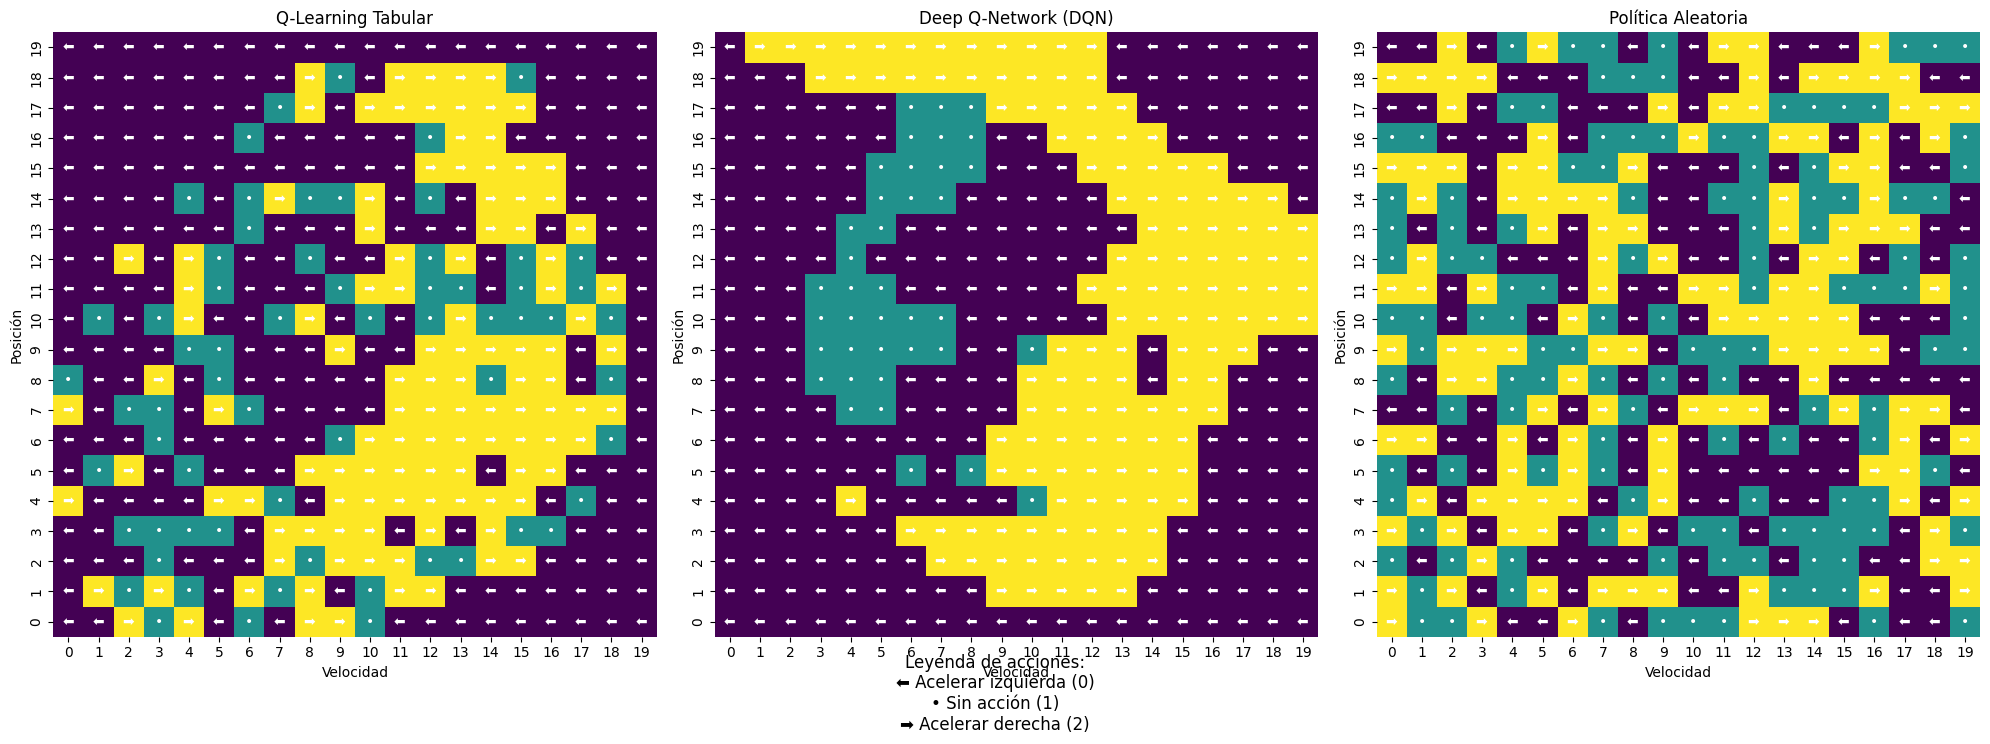

In [ ]:
visualizar_politicas_comparadas(
    agent_q=agente_q,
    agent_dqn=agent,
    agent_random=politica,
    env=env,
    bins=(20, 20)
)


- 📊 Panel izquierdo: Q-Learning Tabular


Cada color representa una acción: izquierda (0), nada (1) o derecha (2).

El patrón tiene leve forma de "zig-zag", la política aprendida depende del estado (posición y velocidad).

En zonas con poca velocidad, el agente oscila entre izquierda y derecha para ganar impulso, incluso un poco mas a la izquierda. (acción 0 y 2).

Logra aprender en algunos sectores una política homogénea, pero aún existen sectores en los que sigue habiendo algo de caos y falta de aprendizaje.



- 📊 Panel central: Deep Q-Network (DQN)


Zonas grandes con decisiones más homogéneas.

Cambios más abruptos entre regiones con diferente acción.

El DQN ha aprendido una política más general, debido a que trabaja en el espacio continuo y suaviza decisiones.

Hay una región clara donde decide "dar impulso" (izquierda o derecha), y otra donde ya avanza.


- 📊 Panel derecho: Política Aleatoria


Aquí hay una distribución completamente caótica de colores, sin patrón aparente.

Cada acción se elige al azar, sin relación con el estado (posición/velocidad).

Esto resulta en una política ineficiente: el agente nunca logra alcanzar la cima con consistencia.



## **2.4.b)** **Comparacion de la evolución de las recompensas**

---



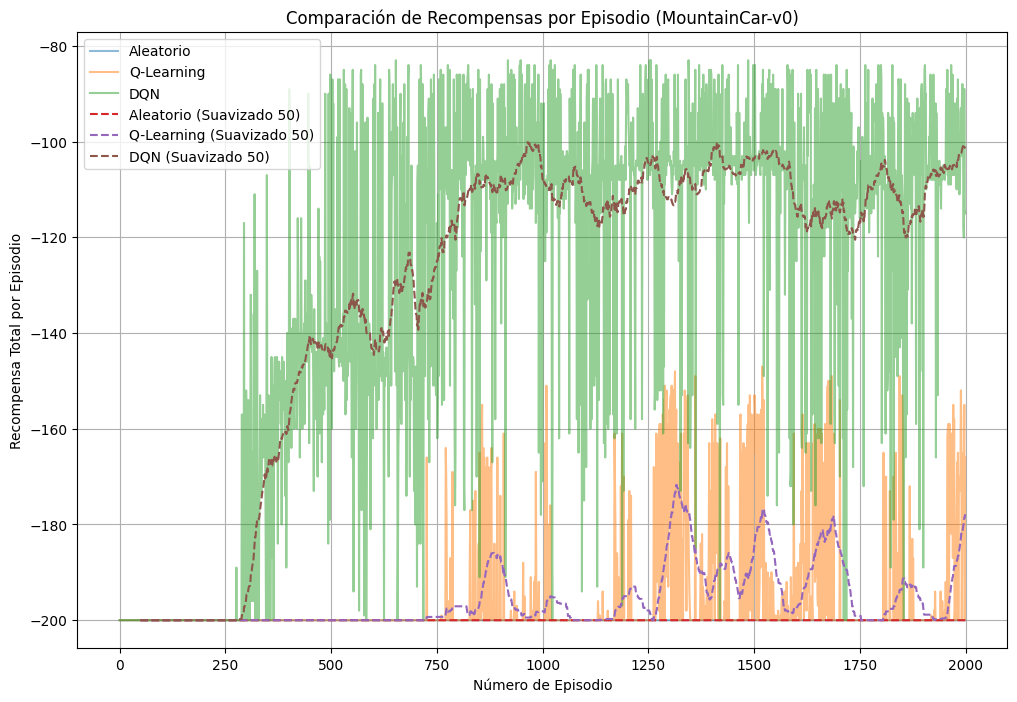

In [ ]:
# prompt: crear gráfico que compare recompensas_aleatorio, recompensas_qlearning y recompensas_dqn. Eje x es nro de episodio y el eje Y valor de la recompensa. Agrega tambien un grafico suavizando la curva con el promedio movil

# Función para suavizar la curva con promedio móvil
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size), 'valid') / window_size

# Definir el tamaño de la ventana para el promedio móvil
window_size = 50  # Puedes ajustar este valor

# Calcular el promedio móvil
recompensas_aleatorio_suavizadas = moving_average(recompensas_aleatorio, window_size)
recompensas_qlearning_suavizadas = moving_average(recompensas_qlearning, window_size)
recompensas_dqn_suavizadas = moving_average(recompensas_dqn, window_size)

# Crear el gráfico de comparación
plt.figure(figsize=(12, 8))

# Gráficos de recompensa por episodio
plt.plot(recompensas_aleatorio, label='Aleatorio', alpha=0.5)
plt.plot(recompensas_qlearning, label='Q-Learning', alpha=0.5)
plt.plot(recompensas_dqn, label='DQN', alpha=0.5)

# Gráficos de recompensa suavizada (promedio móvil)
plt.plot(np.arange(window_size - 1, len(recompensas_aleatorio)), recompensas_aleatorio_suavizadas, label=f'Aleatorio (Suavizado {window_size})', linestyle='--')
plt.plot(np.arange(window_size - 1, len(recompensas_qlearning)), recompensas_qlearning_suavizadas, label=f'Q-Learning (Suavizado {window_size})', linestyle='--')
plt.plot(np.arange(window_size - 1, len(recompensas_dqn)), recompensas_dqn_suavizadas, label=f'DQN (Suavizado {window_size})', linestyle='--')


plt.xlabel('Número de Episodio')
plt.ylabel('Recompensa Total por Episodio')
plt.title('Comparación de Recompensas por Episodio (MountainCar-v0)')
plt.legend()
plt.grid(True)
plt.show()


 Lo que podemos observar en las gráficas es:

 - La política aleatoria claramente no obtiene recompensas positivas debido a que no logró llegar a la cima nunca.


- Q-Learning : Muestra una progresión a partir del episodio 700, el promedio se mantiene en valores bajos, lo que indica que  ha aprendido una política parcialmente eficaz.

- DQN: Aprende más rápidamente que Q-Learning, con un aumento pronunciado desde el episodio 300. Al final del entrenamiento alcanza recompensas promedio superiores y con menos oscilaciones mostrando mejor rendimiento general.

## **2.4.c)** **Comparación de la tasa de éxito**

---



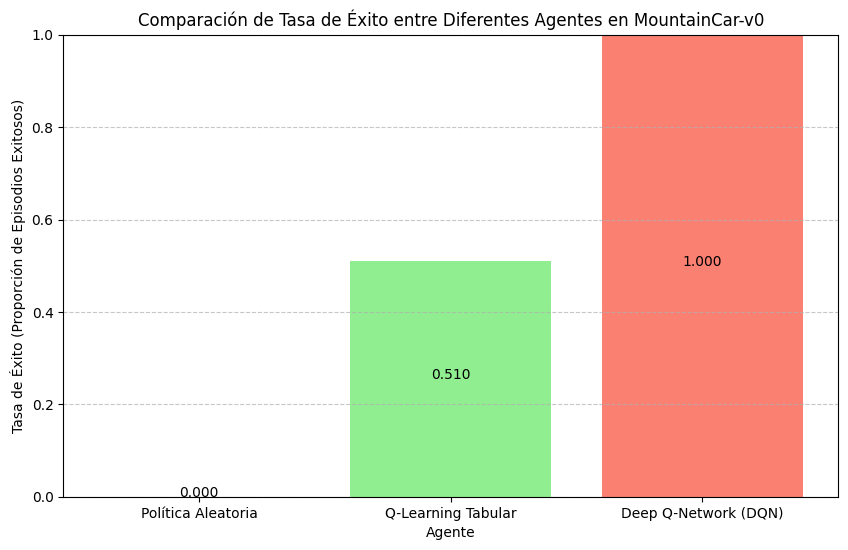

In [ ]:
# prompt:  comparar tasa_exito_aleatorio, tasa_exito_qlearning, tasa_exito_dqn en un gráfico de barras

# Preparar los datos para el gráfico de barras
etiquetas = ['Política Aleatoria', 'Q-Learning Tabular', 'Deep Q-Network (DQN)']
tasas_exito = [tasa_exito_aleatorio, tasa_exito_qlearning, tasa_exito_dqn]

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(etiquetas, tasas_exito, color=['skyblue', 'lightgreen', 'salmon'])

# Añadir títulos y etiquetas
plt.xlabel('Agente')
plt.ylabel('Tasa de Éxito (Proporción de Episodios Exitosos)')
plt.title('Comparación de Tasa de Éxito entre Diferentes Agentes en MountainCar-v0')
plt.ylim(0, 1) # La tasa de éxito va de 0 a 1

# Añadir los valores de la tasa de éxito encima de cada barra
for i, tasa in enumerate(tasas_exito):
    plt.text(i, tasa / 2, f'{tasa:.3f}', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

🏁 **Comparación de Tasa de Éxito:**

- Política Aleatoria: 0.00 (no llega a la cima)

- Q-Learning Tabular: 0.46

- DQN: 1.00 (100%)

La tasa de éxito representa la proporción de episodios en los que el agente logró alcanzar la cima de la montaña. El agente DQN resuelve el entorno en todos los episodios de evaluación, mientras que Q-Learning lo hace en menos de la mitad. Politica Aleatoria ni siquiera llega a la cima una vez.

DQN supera ampliamente a los otros enfoques en cuanto a desempeño final, logrando una política completamente exitosa.

## **2.4.d)** **Evolución de Epsilon (solo para algoritmos que usan exploración)**

---



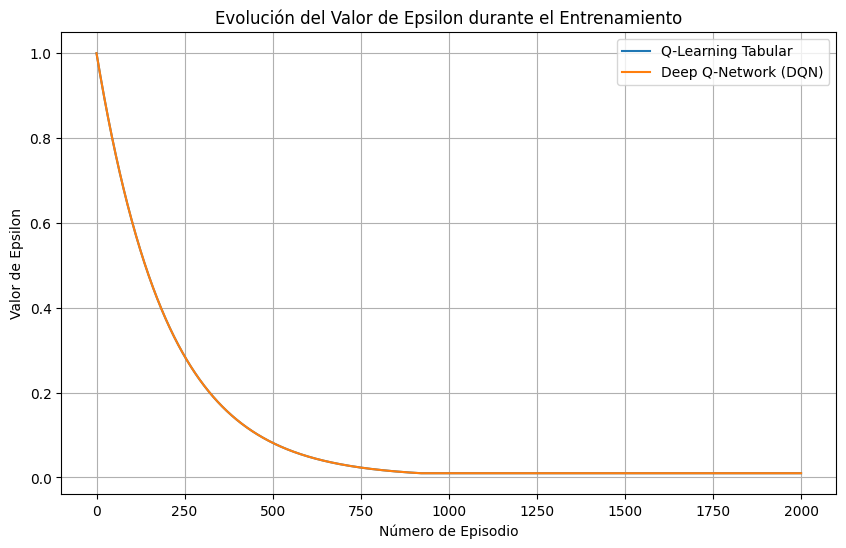

In [ ]:
# prompt:  Crear un gráfico para comparar agente_qlearning.epsilons y agente_dqn.epsilons siendo x el nro de episodios y el eje Y el valor de epsilon.

# Crear el gráfico para comparar la evolución de Epsilon
plt.figure(figsize=(10, 6))

# Gráfico de epsilon para Q-Learning Tabular
# Asegúrate de que agente_q.epsilons tenga la longitud correcta (igual al número de episodios de entrenamiento)
plt.plot(agente_q.epsilons, label='Q-Learning Tabular')

# Gráfico de epsilon para DQN
# Asegúrate de que agent.epsilons tenga la longitud correcta (igual al número de episodios de entrenamiento)
plt.plot(agent.epsilons, label='Deep Q-Network (DQN)')


plt.xlabel('Número de Episodio')
plt.ylabel('Valor de Epsilon')
plt.title('Evolución del Valor de Epsilon durante el Entrenamiento')
plt.legend()
plt.grid(True)
plt.show()


📈  **Evolución del Valor de Epsilon (Exploración):**

Ambos agentes (Q-Learning y DQN) comparten un esquema de decaimiento exponencial de epsilon, lo que indica que comienzan con alta exploración y van disminuyendo progresivamente hasta alcanzar una política más explotativa.

Los que nos permite entender esto es que el desempeño de cada agente,  la diferencia de rendimiento, se atribuye al algoritmo, no a la estrategia de exploración.



## **2.4.e)** **Evolución de la pérdida en DQN**

---



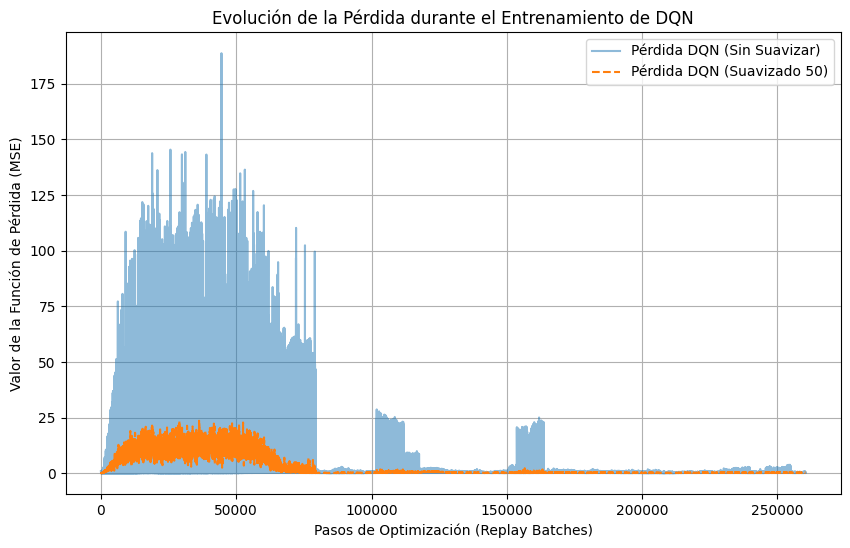

In [ ]:
# prompt:  Graficar agente_dqn.losses que representa la pérdida durante el entrenamiento de DQN. Mostrar con y sin promedio móvil

# Gráfico de la pérdida (Loss) del agente DQN
plt.figure(figsize=(10, 6))

# Gráfico sin promedio móvil
plt.plot(agent.losses, label='Pérdida DQN (Sin Suavizar)', alpha=0.5)

# Gráfico con promedio móvil
if len(agent.losses) > window_size:
    dqn_losses_suavizadas = moving_average(agent.losses, window_size)
    plt.plot(np.arange(window_size - 1, len(agent.losses)), dqn_losses_suavizadas, label=f'Pérdida DQN (Suavizado {window_size})', linestyle='--')

plt.xlabel('Pasos de Optimización (Replay Batches)')
plt.ylabel('Valor de la Función de Pérdida (MSE)')
plt.title('Evolución de la Pérdida durante el Entrenamiento de DQN')
plt.legend()
plt.grid(True)
plt.show()

📉 **Evolución de la Pérdida durante el Entrenamiento de DQN**:

Inicialmente. la pérdida es alta y muy variable porque el agente está aprendiendo y ajustando pesos.
Luego se estabiliza y baja a valores cercanos a 0,aquí hay evidencia de convergencia estable.

Los bloques vacíos indican pausas (por ejemplo, falta de replay en esos momentos, puede ser porque no había muestras suficientes).

La curva suavizada confirma el descenso sostenido de la pérdida que sugiere que el DQN está aprendiendo efectivamente.

## **2.4.f)** **Comparación del número promedio de pasos**

---



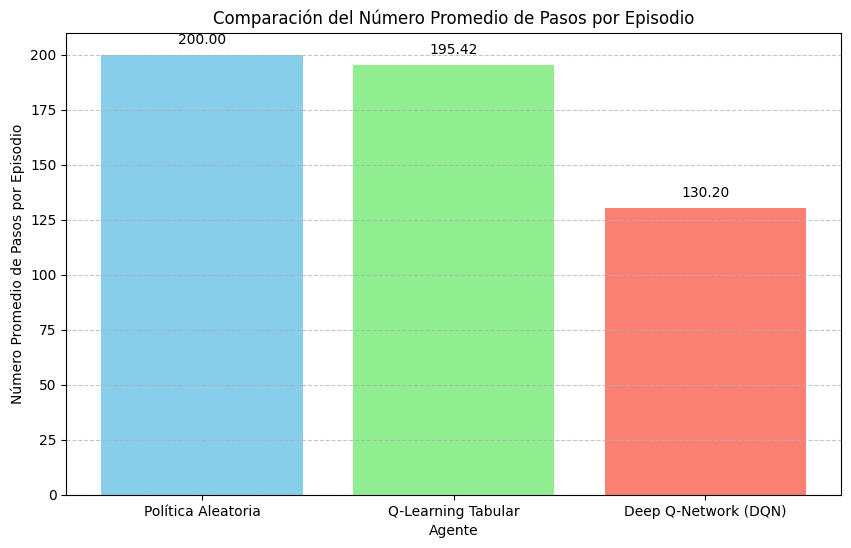

In [ ]:
# prompt: Genera un grafico que compare el Número promedio de pasos por episodio para cada uno de los agentes entrenados. Aleatorio, Q-learning y DQN

# Calcular el número promedio de pasos por episodio para cada agente
# Para la política aleatoria, la recompensa es -1 por paso, por lo tanto,
# el número de pasos es el negativo de la recompensa total.
pasos_aleatorio = [-r for r in recompensas_aleatorio]
pasos_qlearning = [-r for r in recompensas_qlearning]
pasos_dqn = [-r for r in recompensas_dqn]

# Calcular el promedio de pasos para cada agente
promedio_pasos_aleatorio = np.mean(pasos_aleatorio)
promedio_pasos_qlearning = np.mean(pasos_qlearning)
promedio_pasos_dqn = np.mean(pasos_dqn)

# Preparar los datos para el gráfico de barras
etiquetas_pasos = ['Política Aleatoria', 'Q-Learning Tabular', 'Deep Q-Network (DQN)']
promedios_pasos = [promedio_pasos_aleatorio, promedio_pasos_qlearning, promedio_pasos_dqn]

# Crear el gráfico de barras para el número promedio de pasos
plt.figure(figsize=(10, 6))
plt.bar(etiquetas_pasos, promedios_pasos, color=['skyblue', 'lightgreen', 'salmon'])

# Añadir títulos y etiquetas
plt.xlabel('Agente')
plt.ylabel('Número Promedio de Pasos por Episodio')
plt.title('Comparación del Número Promedio de Pasos por Episodio')

# Añadir los valores promedio de pasos encima de cada barra
for i, promedio in enumerate(promedios_pasos):
    plt.text(i, promedio + 5, f'{promedio:.2f}', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


🚶‍♂️ **Comparación del Número Promedio de Pasos por Episodio:**

- Política Aleatoria: 200 pasos (máximo)

- Q-Learning Tabular: 195.41 pasos

- DQN: 130.20 pasos


El número de pasos promedio refleja qué tan rápido el agente aprende a resolver la tarea. El agente DQN necesita muchos menos pasos en promedio para alcanzar el objetivo, lo que indica un comportamiento más eficiente y aprendido y que ha logrado una política más efectiva que acelera la llegada al objetivo.

## **2.4.g) Comparación del timpo de entrenamiento**

---



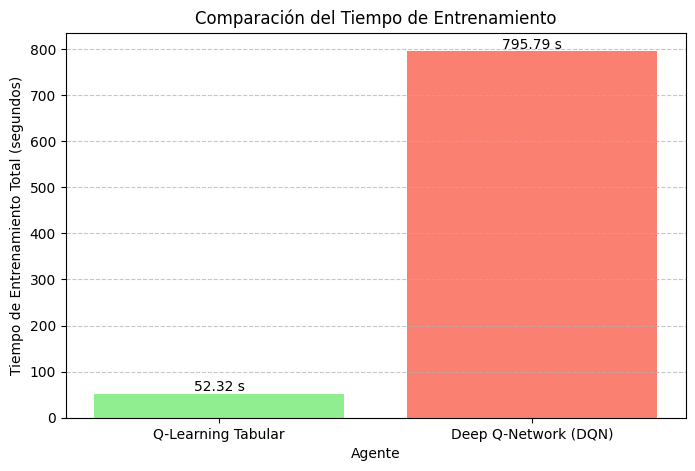

In [ ]:
# prompt: Genera un gráfico que compare el  tiempo de entrenamiento entre todos los agentes q-learning y DQN

# Preparar los datos para el gráfico de barras de tiempo de entrenamiento
etiquetas_tiempo = ['Q-Learning Tabular', 'Deep Q-Network (DQN)']
tiempos_entrenamiento = [duracion_qlearning, duracion_dqn]

# Crear el gráfico de barras para el tiempo de entrenamiento
plt.figure(figsize=(8, 5))
plt.bar(etiquetas_tiempo, tiempos_entrenamiento, color=['lightgreen', 'salmon'])

# Añadir títulos y etiquetas
plt.xlabel('Agente')
plt.ylabel('Tiempo de Entrenamiento Total (segundos)')
plt.title('Comparación del Tiempo de Entrenamiento')

# Añadir los valores de tiempo encima de cada barra
for i, tiempo in enumerate(tiempos_entrenamiento):
    plt.text(i, tiempo + 5, f'{tiempo:.2f} s', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


📊  **Comparación del Tiempo de Entrenamiento:**

- Q-Learning Tabular: 56.25 segundos

- DQN: 706.83 segundos (12,5 veces más lento)


El agente DQN requiere un tiempo de entrenamiento mucho mayor que se debe a la complejidad computacional de las redes neuronales, el uso de optimizadores y el proceso de aprendizaje a partir de lotes de experiencia.

Si bien DQN es más potente, también es mucho más costoso en términos de tiempo de cómputo. Para entornos simples o con recursos limitados, siempre que el rendimiento sea aceptable, Q-Learning tabular puede ser preferible.

# Referencias:

- **POST**: Train an AI Agent to play Mountain Car with Reinforcement Learning: https://isaac-the-man.dev/posts/reinforcement-learning-mountain-car/?utm_source=chatgpt.com

- **VIDEO**: Deep Q-Network (DQN) Applied to Gymnasium Mountain Car | Python+Pytorch Deep Reinforcement Learning: https://www.youtube.com/watch?v=oceguqZxjn4

- **GIMNASIUM DOCUMENTATION**: https://gymnasium.farama.org/environments/classic_control/mountain_car/

- **PROMPTS COLAB**:
-- "Crea una función para discretizar el espacio de estados continuos del entorno MountainCar-v0 en índices enteros".
-- "Crea una función para visualizar comparativamente las políticas de tres agentes (Q-learning, DQN, y uno aleatorio) en MountainCar-v0, usando un grid de 20x20 de estados (posición, velocidad). Muestra en cada celda la acción elegida por cada agente como un símbolo. Incluye leyenda."
-- "Crea una clase PoliticaAleatoria para el entorno MountainCar-v0.
Debe seleccionar acciones al azar (np.random.randint).
Incluir un método entrenar(episodios) que registre la recompensa total por episodio y cuente los éxitos (cuando el auto alcanza posición ≥ 0.5).
Mostrar progreso cada 200 episodios y calcular recompensa promedio y tasa de éxito final.
Debe ser compatible con funciones que usan discretizar_estado, aunque no use una tabla Q."
-- "Crea una clase QLearningTabular para entrenar un agente Q-learning en MountainCar-v0, discretizando el espacio de estados con bins.
Debe incluir métodos seleccionar_accion, actualizar_q, decay_epsilon, entrenar y evaluar.
Durante el entrenamiento, registra recompensas, tasa de éxito y tiempo total.
En evaluar mide recompensa promedio y tasa de éxito.
Muestra estadísticas cada 200 episodios."
-- "crear gráfico que compare recompensas_aleatorio, recompensas_qlearning y recompensas_dqn. Eje x es nro de episodio y el eje Y valor de la recompensa. Agrega tambien un grafico suavizando la curva con el promedio movil"
-- "comparar tasa_exito_aleatorio, tasa_exito_qlearning, tasa_exito_dqn en un gráfico de barras"
-- "Crear un gráfico para comparar agente_qlearning.epsilons y agente_dqn.epsilons siendo x el nro de episodios y el eje Y el valor de epsilon."
-- "Graficar agente_dqn.losses que representa la pérdida durante el entrenamiento de DQN. Mostrar con y sin promedio móvil"
-- "Genera un grafico que compare el Número promedio de pasos por episodio para cada uno de los agentes entrenados. Aleatorio, Q-learning y DQN"
-- "Genera un gráfico que compare el  tiempo de entrenamiento entre todos los agentes q-learning y DQN"